In [6]:
# Import required libraries
import numpy as np
import xarray as xr
import pandas as pd

def calculate_agri_lai_mean(a, b, agri_threshold=0.01):
    """
    Calculate the mean LAI contribution percentage in agricultural areas
    
    Parameters:
        a: LAI contribution percentage data array [grid cells, time steps]
        b: Agricultural area percentage data array [grid cells, time steps]
        agri_threshold: Threshold for defining agricultural areas (default >1% considered agricultural)
    
    Returns:
        Mean LAI contribution percentage in agricultural areas for each time step [time steps]
    """
    # 1. Define agricultural areas (grid cells where agricultural percentage > threshold)
    agricultural_mask = b > agri_threshold  # shape: [733, 216]
    
    # 2. Calculate mean LAI contribution in agricultural areas for each time step
    # Initialize result array
    mean_lai_agri = np.zeros(a.shape[1])  # shape: [216]
    
    for t in range(a.shape[1]):
        # Get current time step LAI data and agricultural mask
        lai_t = a[:, t]
        agri_mask_t = agricultural_mask[:, t]
        
        # Calculate mean LAI in agricultural areas (ignore non-agricultural areas and NaN values)
        if np.any(agri_mask_t):
            mean_lai_agri[t] = np.nanmean(lai_t[agri_mask_t])
        else:
            mean_lai_agri[t] = np.nan
    
    return mean_lai_agri


def calculate_high_sensitivity_ratio(a, b):
    """
    Calculate the proportion of high sensitivity areas (>95th percentile) within agricultural areas
    
    Parameters:
        a: Sensitivity data array [grid cells, time steps]
        b: Agricultural area percentage data array [grid cells, time steps]
    
    Returns:
        Proportion of high sensitivity agricultural areas for each time step [time steps]
    """
    # 1. Calculate 95th percentile threshold for each time step
    # Compute along grid dimension to get threshold for each time step [time steps]
    percentiles = np.percentile(abs(a), 50)  # shape: [216]
    
    # 2. Identify high sensitivity areas (>95th percentile)
    high_sensitivity = abs(a) > percentiles  # shape: [733, 216]
    
    # 3. Calculate proportion of high sensitivity areas within agricultural areas
    # Define agricultural areas as grid cells with agricultural percentage > 0
    agricultural_areas = b > 10  # shape: [733, 216]
    
    # Grid points with high sensitivity in agricultural areas
    high_sens_in_agri = high_sensitivity & agricultural_areas  # shape: [733, 216]
    
    # Calculate proportion for each time step
    # Numerator: number of high sensitivity grid points in agricultural areas
    numerator = np.sum(high_sens_in_agri, axis=0)  # shape: [216]
    
    # Denominator: total number of agricultural grid points
    denominator = np.sum(agricultural_areas, axis=0)  # shape: [216]
    
    # Calculate ratio (avoid division by zero)
    ratio = np.divide(numerator, denominator, 
                     out=np.zeros_like(numerator, dtype=float),
                     where=denominator!=0)
    
    return ratio

In [2]:
# cropland=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/cropland.npy',)
# receive_mean=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_masked_lai_months.npy')
# lats=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/lats_overlap_upwind_plot.npy',)
# lons=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/lons_overlap_upwind_plot.npy',)
# perc_lai_somo=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_masked_0.001_lai_perc.npy',)

# result_ratio = calculate_high_sensitivity_ratio(receive_mean, cropland)
# result = calculate_agri_lai_mean(perc_lai_somo, cropland)

# cropland_mean=np.nanmean(cropland,axis=1)
# receive_mean_mean=np.nanmean(receive_mean,axis=1)

# np.save('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/cropland_mean.npy',cropland_mean)
# np.save('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/cropland_receive.npy',receive_mean_mean)

In [3]:
def get_da(arr):
    # Load latitude and longitude coordinate arrays from numpy files
    lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats_737.npy")
    lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons_737.npy")
    
    # Create DataFrame with values and corresponding coordinates, then pivot to 2D grid format
    df_pivot = pd.DataFrame({'values': arr, 'lat': lats, 'lon': lons}).pivot_table(
        index='lat', columns='lon', values='values')
    
    # Convert pivoted DataFrame to xarray DataArray with proper dimensions and coordinate labels
    da = xr.DataArray(df_pivot, dims=('lat', 'lon'), 
                     coords={'lat': df_pivot.index, 'lon': df_pivot.columns})
    
    return da

In [4]:
cropland_mean=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/cropland_mean.npy',)
receive_mean_mean=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/cropland_receive.npy',)

In [13]:
# Create a copy of the cropland_mean array to avoid modifying the original
cropland_mean_masked = cropland_mean.copy()
# Mask values where cropland percentage is less than 10% (set to NaN)
cropland_mean_masked[cropland_mean < 10] = np.nan
# Convert the masked array to a DataArray using the get_da function
da_cropland_mean = get_da(cropland_mean_masked)

In [14]:
# Create a copy of the receive_mean_mean array to avoid modifying the original
receive_mean_mean_masked = receive_mean_mean.copy()
# Apply the same mask as cropland data: mask values where cropland percentage < 10%
receive_mean_mean_masked[cropland_mean < 10] = np.nan
# Convert the masked array to a DataArray using the get_da function
da_receive_mean_mean = get_da(receive_mean_mean_masked)

In [10]:
# Import required libraries
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D
import rioxarray

# Set universal plot style to seaborn paper theme
uplt.rc.style = 'seaborn-v0_8-paper'
# Update plot configuration parameters
uplt.rc.update({
    'tick.len': 2.0,        # Set tick length
    'tick.dir': 'in',       # Set tick direction (inward)
    'font.largesize': 12,   # Set large font size
    'font.smallsize': 10    # Set small font size
})

# Define longitude and latitude limits for plotting
lonlim = (-82, -32)
latlim = (-60, 15)

# Load Amazon shapefile and read into GeoDataFrame
amazon_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/amazonia_polygons.shp"
amazon_vector = gpd.read_file(amazon_shapefile)

# Dissolve all polygons into a single multi-polygon feature
# (Alternative commented line shows filtering for specific region before dissolving)
amazon_vector = amazon_vector.dissolve()
# amazon_vector = amazon_vector[amazon_vector['name'] == 'Amazonia - sensu stricto'].dissolve()

# Select the first (and only) feature from the dissolved GeoDataFrame
amazon_border = amazon_vector.loc[[0]]

# Load global geography regions shapefile for additional geographic context
geography_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/ne_10m_geography_regions_polys.shp"
geography_vector = gpd.read_file(geography_shapefile)

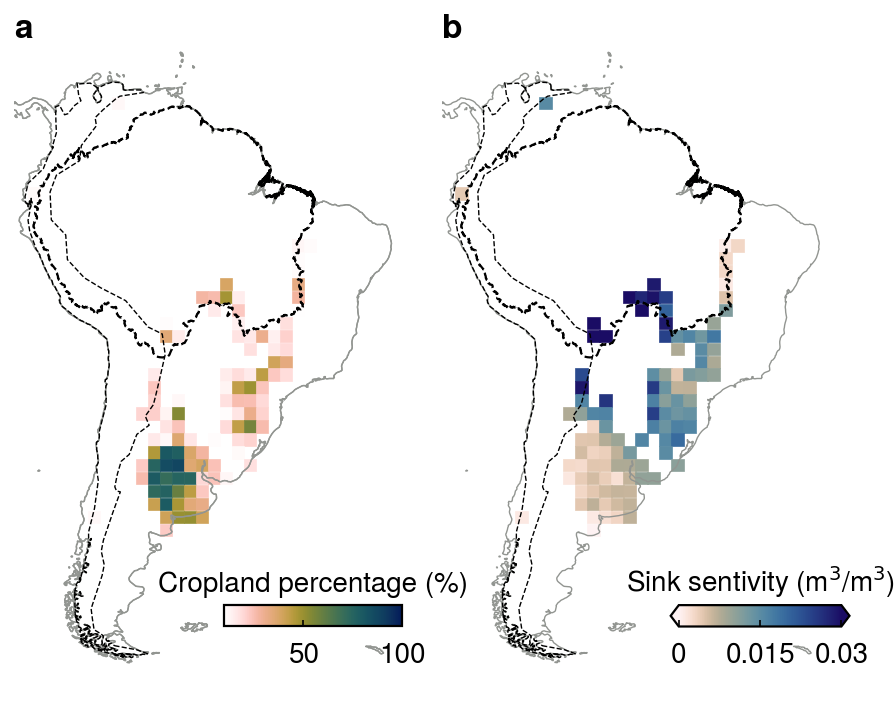

In [21]:
# Define map projection (PlateCarree commented alternative shows AlbersEqualArea option)
# proj = ccrs.AlbersEqualArea(central_longitude=-60, central_latitude=-20, standard_parallels=(-10, -40))
proj = ccrs.PlateCarree()

# Define subplot arrangement (single row with two subplots)
arrray = [  # the "picture" (0 == nothing, 1 == subplot A, 2 == subplot B, etc.)
    [1, 2],
]

# Create figure with specified parameters
fig = uplt.figure(refwidth=2, share=False, span=False, tight=True)
# Create subplots with specified projection and layout parameters
axs = fig.subplots(arrray, projection=proj, abc=True, width_ratios=[1, 1], height_ratios=[1])
# Format axes with longitude and latitude limits
axs.format(lonlim=lonlim, latlim=latlim, linewidth=0)

# First subplot: Cropland percentage
ax = axs[0]
# Create scatter plot showing cropland percentage with square markers
im = ax.scatter(lons, lats, c=cropland_mean_masked, cmap='batlowW_r', marker='s',
                 vmin=10, vmax=100, s=20, transform=proj)

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

# Create colorbar for cropland percentage
cax = fig.add_axes([0.25, 0.12, 0.2, 0.03], title='Cropland percentage (%)', titlesize=10)
fig.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    extend='neither',
    ticks=[0, 50, 100],
)
# Add coastline feature again (duplicate line)
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

################################################
# Second subplot: Sink sensitivity
ax = axs[1]
# Create scatter plot showing sink sensitivity with square markers
im = ax.scatter(lons, lats, c=receive_mean_mean_masked, cmap='lapaz_r', marker='s',
                 vmin=0, vmax=0.03, s=20, transform=proj)

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')

# Create colorbar for sink sensitivity
cax = fig.add_axes([0.75, 0.12, 0.2, 0.03], title='Sink sensitivity (m${^3}$/m${^3}$)', titlesize=10)
fig.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    extend='both',
    ticks=[0, 0.015, 0.03],
)
# Add coastline feature
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)